In [ ]:
%load_ext autoreload
%autoreload 2

from utils import make_spikes_responses_df
import os 
import numpy as np
import pandas as pd
import yaml
import shutil
from utils import read_pattern_json, preprocess_pattern_stimulations_df

# =====================
# Load Configuration
# =====================
CONFIG_PATH = "config.yaml"  # Change this to use a different config file

with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

# Extract data settings from config
datadir = cfg['datadir']
problematic_neurons = cfg['problematic_neurons']

spikes_df = make_spikes_responses_df(os.path.join(datadir, "spkVecs.npy"))
spikes_df.head(5)

# optionally, drop neurons with very high firing rates that may be multi-unit activity or artifacts
spikes_df = spikes_df[~spikes_df['neuron_id'].isin(problematic_neurons)]
print (spikes_df['neuron_id'].nunique(), " unique neurons recorded after dropping problematic neurons")
pattern_registrations_path = os.path.join(datadir, "pattern_registrations.pkl")
pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json(pattern_registrations_path), align_to_stim=True)
spikes_df['timestamp']
pattern_df.head(30)

In [ ]:
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = spikes_df['neuron_id'].unique()
spiking_neuron_to_index = {neuron: idx for idx, neuron in enumerate(spiking_neurons)}
spiking_neurons.sort()

print (f"Total unique stimulation channels used: {len(channel_to_index)}")
print ("Stimulation channel names: ", [str(int(k)) for k in sorted(channel_to_index.keys())])

print (f"Total spiking neurons recorded: {len(spiking_neurons)}")
print ("Spiking neuron names: ", spiking_neurons)


In [ ]:
from utils import trial_breakout_spikes_and_patterns

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = trial_breakout_spikes_and_patterns(
    spikes_df,
    pattern_df,
    channel_to_index,
    spiking_neurons=spiking_neurons,
    spiking_neuron_to_index=spiking_neuron_to_index,
    
)

# Note pattern stims and polarities are keyed by pattern_name while spike_responses and timing_to_pattern are keyed by timing index. timing_to_pattern connects timing index to pattern name in case you need it.
# spikes are recorded in 1 ms resolution in this spikes_responses

print(f"Total unique patterns: {len(pattern_stims)}")
print(f"Total trials (spike responses): {len(spike_responses)}")
print(f"Oracle trials: {unique_trials['is_oracle'].sum()}")
print(f"Non-oracle trials: {(~unique_trials['is_oracle']).sum()}")



In [ ]:
# Native frame resolution polarity plots to see if stimulation timings on oracle trials vary between trials 
from viz import plot_stimulation_polarity_frame_res_alpha
for oracle_trial in unique_trials[unique_trials['is_oracle']]['pattern_name'].unique():
    plot_stimulation_polarity_frame_res_alpha(oracle_trial, pattern_df, savepath=os.path.join(datadir, "stim_viz", "frame_res_alpha"))



In [ ]:
# Plot largest oracle-pattern changes over trials in timing of a given step
for pattern in unique_trials[unique_trials['is_oracle']]['pattern_name'].unique():
    pattern_data = pattern_df[pattern_df['pattern_name'] == pattern] 
    step_starts = pattern_data.groupby(['trial', 'step_index'])['step_start_timestamp'].min().reset_index()
    # join the step_starts back to pattern_data to get the timing of each step start for each trial
    pattern_data = pattern_data.merge(step_starts, on=['trial', 'step_index'], how='left', suffixes=('', '_step_start'))
    # calculate the time difference between each step start and the first step start for that trial
    pattern_data['time_from_first_step'] = pattern_data['step_start_timestamp_step_start'] - pattern_data.groupby('trial')['step_start_timestamp_step_start'].transform('min')
    # scatter of time_from_first_step for each step_index, with one point per trial
    steps = pattern_data[['trial', 'step_index', 'time_from_first_step']].drop_duplicates()
    plt.scatter(steps['step_index'], steps['time_from_first_step'], alpha=0.2, s=15.0)
    
    # Annotate each step_index with the range (min-max) across trials
    step_stats = steps.groupby('step_index')['time_from_first_step'].agg(['min', 'max', 'mean'])
    for step_idx, row in step_stats.iterrows():
        plt.annotate(
            f"{int(row['max'])-int(row['min'])}",
            xy=(step_idx, row['mean']),
            xytext=(step_idx + 0.15, row['mean']),
            fontsize=7,
            va='center',
        )
    
    plt.xlim(0, 10)
    plt.xticks(range(0, 11))
    plt.grid()
    plt.xlabel('Step Index')
    plt.ylabel('Time from First Step (frames)')
    plt.title(f'Pattern {pattern} - Timing of Steps Across Trials')
    plt.savefig(os.path.join(datadir, "stim_viz", "step_timing", f"step_timing_pattern_{pattern}.png"), dpi=150, bbox_inches='tight')
    plt.close()

In [ ]:
# Example: Plot stimulation pattern for a specific pattern (colored by polarity)
from viz import plot_oracle_pattern_average_responses, plot_stimulation_polarity_timeseries
oracle_trials = unique_trials[unique_trials['is_oracle']]['pattern_name'].unique()
for pattern in pattern_df['pattern_name'].unique():
    pattern_name = (int(pattern))
    if pattern_name in oracle_trials:
        plot_stimulation_polarity_timeseries(pattern_stims, pattern_polarities, pattern_name=pattern_name, savepath=os.path.join(datadir, 'stim_viz/oracle/'))
    plot_stimulation_polarity_timeseries(pattern_stims, pattern_polarities, pattern_name=pattern_name, savepath=os.path.join(datadir, 'stim_viz/'))

# plot_oracle_pattern_average_responses(unique_trials, spike_responses, spiking_neurons, savepath=os.path.join(datadir, 'oracle_pattern_averages_bin_fixed/'), plot_duration=600, bin_size=60)

In [ ]:
# Plot ticks for spike_responses[0]
from utils import bin_spike_response
import matplotlib.pyplot as plt
idxs = pattern_df[pattern_df["is_oracle"]]["pattern_timing_index"].unique()
total_time = 600
for idx in idxs: 
    f, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(10, 6), constrained_layout=True)

    # raster: time indices are in ms (columns)
    neuron_indices, time_indices = np.where(spike_responses[idx][:, :total_time] > 0) # remember, spike_responses is in 1 ms resolution (2000 bins max)

    # s=20 controls marker size, marker='|' gives the classic look
    ax[0].scatter(time_indices, neuron_indices, s=20, c='black', marker='|', linewidths=0.8)
    ax[0].set_ylabel('Neuron ID')
    ax[0].set_title('Spike Raster Plot')

    # Determine total time in ms from the 1ms-resolution array
    ax[0].set_xlim(0, total_time)
    ax[0].set_xlabel('Time (ms)')

    # Binned heatmap: ensure the image extent maps columns to the same ms range
    binned = bin_spike_response(spike_responses[idx], bin_size=60, max_time=total_time)
    # binned shape: (n_neurons, n_bins)
    n_neurons_binned, n_bins = binned.shape
    # extent: [x0, x1, y0, y1] where x is time in ms and y is neuron index space
    extent = [0, total_time, n_neurons_binned, 0]
    im = ax[1].imshow(binned, aspect='auto', interpolation='nearest', extent=extent, cmap='viridis')
    ax[1].set_xlabel('Time (ms)')
    ax[1].set_ylabel('Neuron ID')
    ax[1].set_title(f'Binned spike counts ({60} ms bins)')
    ax[1].set_xlim(0, total_time)

    plt.colorbar(im, ax=ax[1], label='Spike count')

    # Other trials
    relevant_pattern = pattern_df[pattern_df["pattern_timing_index"] == idx].loc[:, ["pattern_name", "is_oracle", "trial"]].drop_duplicates()
    this_pattern_name = relevant_pattern["pattern_name"].iloc[0]
    this_pattern_trial = relevant_pattern["trial"].iloc[0]
    avg = np.zeros_like(binned)
    print (relevant_pattern)
    if relevant_pattern['is_oracle'].iloc[0]:
        other_patterns = pattern_df[(pattern_df["pattern_name"] == this_pattern_name) & (pattern_df["trial"] != this_pattern_trial)]
        other_trials = other_patterns["trial"].unique()
        for trial in other_trials: 
            other_trial_data = other_patterns[other_patterns["trial"] == trial]
            other_trial_idx = other_trial_data["pattern_timing_index"].unique()
            assert other_trial_idx.shape[0] == 1
            other_trial_idx = other_trial_idx[0]
            binned_other_trial = bin_spike_response(spike_responses[other_trial_idx], bin_size=60, max_time=total_time)
            avg += binned_other_trial
    avg /= len(other_trials)
    print (np.amax(avg))
    im1 = ax[2].imshow(avg, aspect="auto", interpolation="nearest", extent=extent, cmap='viridis')
    ax[2].set_xlabel('Time (ms)')
    ax[2].set_ylabel('Neuron ID')
    ax[2].set_title(f'Binned spike counts ({60} ms bins average over {len(other_trials)} trials)')
    ax[2].set_xlim(0, total_time)
    plt.colorbar(im1, ax=ax[2], label="Spike count")
    if not os.path.exists(os.path.join(datadir, "oracle_trial_averages")):
        os.makedirs(os.path.join(datadir, "oracle_trial_averages"))
    plt.savefig(os.path.join(datadir, "oracle_trial_averages", f"{this_pattern_name}_{this_pattern_trial}.png"))
    plt.close()

In [ ]:
# find timing_idx for a given pattern_name
from utils import bin_spike_response
import matplotlib.pyplot as plt 

max_avg = -np.inf
oracle_patterns = unique_trials[unique_trials['is_oracle']]['pattern_name'].unique()
print (f"Total unique oracle patterns: {len(oracle_patterns)}")
for oracle in oracle_patterns:     
    if oracle == 4033:
        show_a = True
    else:
        show_a = False
    print (f"Oracle pattern: {oracle}")
    timing_indices = unique_trials[unique_trials['pattern_name'] == oracle]['pattern_timing_index'].tolist()
    print (f"Timing indices for pattern {oracle}: {timing_indices}")
    a = np.zeros((len(spiking_neurons), 100))
    for t in timing_indices:
        a += bin_spike_response(spike_responses[t], bin_size=10, max_time=1000, remainder="append")
    a /= len(timing_indices)
    if np.amax(a) > max_avg:
        max_avg = np.amax(a)
        print (f"New max average spike rate found: {max_avg} for pattern {oracle}")
    if show_a:
        plt.figure(figsize=(10,6))
        plt.imshow(a, aspect='auto', cmap='hot')
        plt.colorbar(label='Average Spike Count per Bin')
        plt.title(f'Average Binned Spike Response for Oracle Pattern {oracle}')
        plt.xlabel('Time Bins (60 ms each)')
        plt.ylabel('Neurons')
        plt.show()
print(f"Overall max average spike rate across oracle patterns: {max_avg}")


In [ ]:
plot_oracle_pattern_average_responses(unique_trials, spike_responses, spiking_neurons, savepath=os.path.join(datadir, 'oracle_pattern_averages_bin_fixed_10/'), plot_duration=1000, bin_size=10)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from datetime import datetime
import json
import logging

from utils import BinnedStimSpikeDataset, DELAY_MODE_TO_INDEX, NO_STIM_INDEX, NUM_STIM_LEVELS, PillowDataset
from models import StimToSpikeMLP, StimToSpikeCNN, SimpleCausalSpikeCNN, SpikeRNN
from viz import plot_spike_bin_distribution

# =====================
# Extract Configuration Values
# =====================
INFERENCE_MODE = cfg['inference_mode']
ARTIFACT_PATH = cfg['artifact_path']
SEED = cfg['seed']
SPLIT_MODE = cfg['split_mode']

# Dataset Configuration
INPUT_BIN_SIZE_MS = cfg['input_bin_size_ms']
OUTPUT_BIN_SIZE_MS = cfg['output_bin_size_ms']
BIN_SIZE_FRAMES = INPUT_BIN_SIZE_MS * 30  # For visualization (30 kHz)
BIN_SIZE_MS = INPUT_BIN_SIZE_MS  # Backwards-compatible alias for visualization
N_INPUT_BINS = cfg['n_input_bins']
N_OUTPUT_BINS = cfg['n_output_bins']
OUTPUT_OFFSET = cfg['output_offset']
MAX_TIME_MS = cfg['max_time_ms']
BATCH_SIZE = cfg['batch_size']
ENCODING_MODE = cfg['encoding_mode']
INIT_STATE = cfg.get('init_state', False)
N_INITIAL_STATE_BINS = cfg.get('n_initial_state_bins', 1)  # For RNN models
HISTORY = cfg.get('history', 0)  # Number of previous output bins to include as input (for 'current' encoding)
# When using 'current' encoding with history, spike history is concatenated into the input
# tensor, so the dataset returns 2 elements (not 3). Override USE_INIT_STATE accordingly.
if ENCODING_MODE == 'current' and HISTORY > 0:
    USE_INIT_STATE = False
else:
    USE_INIT_STATE = INIT_STATE
# Create timestamped results folder for this run
if INFERENCE_MODE and ARTIFACT_PATH:
    RUN_DIR = ARTIFACT_PATH
else:
    timestamp = datetime.now().strftime("binned_%Y-%m-%d_%H-%M-%S")
    RUN_DIR = os.path.join("results", timestamp)
    os.makedirs(RUN_DIR, exist_ok=True)

# =====================
# Save a copy of the config file to the run directory
# =====================
config_save_path = os.path.join(RUN_DIR, 'config.yaml')
shutil.copy(CONFIG_PATH, config_save_path)

# =====================
# Setup Logging
# =====================
# Remove any existing handlers to avoid duplicate logs
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log_file = os.path.join(RUN_DIR, "experiment.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()  # Also output to console
    ]
)
logger = logging.getLogger(__name__)

logger.info(f"{'='*50}")
logger.info(f"Experiment run directory: {RUN_DIR}")
logger.info(f"Config file: {CONFIG_PATH} (copied to {config_save_path})")
logger.info(f"Inference mode: {INFERENCE_MODE}")
logger.info(f"Random seed: {SEED}")
if INFERENCE_MODE:
    logger.info(f"Loading artifacts from: {ARTIFACT_PATH}")
logger.info(f"{'='*50}")

# =====================
# Create Train/Val/Test Splits
# =====================
all_timing_indices = list(spike_responses.keys())
logger.info(f"Total trials: {len(all_timing_indices)}")

# Get unique trials info for splitting
unique_trials_info = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()

if SPLIT_MODE == 'oracle':
    oracle_timing_indices = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    sample_timing_indices = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    
    logger.info(f"Oracle trials: {len(oracle_timing_indices)} (50 patterns × 10 trials)")
    logger.info(f"Sample trials: {len(sample_timing_indices)}")
    
    test_indices = oracle_timing_indices
    train_indices, val_indices = train_test_split(sample_timing_indices, test_size=0.15, random_state=SEED)
    
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

elif SPLIT_MODE == 'random':
    train_val_indices, test_indices = train_test_split(all_timing_indices, test_size=0.15, random_state=SEED)
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.176, random_state=SEED)
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

logger.info(f"Dataset config: input_bin_size={INPUT_BIN_SIZE_MS}ms, output_bin_size={OUTPUT_BIN_SIZE_MS}ms, "
            f"n_input_bins={N_INPUT_BINS}, n_output_bins={N_OUTPUT_BINS}, output_offset={OUTPUT_OFFSET}, encoding_mode={ENCODING_MODE}")

# Create datasets
train_dataset = PillowDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=train_indices, 
    input_bin_size_ms=INPUT_BIN_SIZE_MS, 
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS, 
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, 
    max_time_ms=MAX_TIME_MS, 
    output_offset=OUTPUT_OFFSET,
    encoding_mode=ENCODING_MODE,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    history=HISTORY,
    logger=logger
)

val_dataset = PillowDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=val_indices, 
    input_bin_size_ms=INPUT_BIN_SIZE_MS, 
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS, 
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, 
    max_time_ms=MAX_TIME_MS, 
    output_offset=OUTPUT_OFFSET,
    encoding_mode=ENCODING_MODE,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    history=HISTORY,
    logger=logger
)
test_dataset = PillowDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=test_indices, 
    input_bin_size_ms=INPUT_BIN_SIZE_MS, 
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS, 
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, 
    max_time_ms=MAX_TIME_MS, 
    output_offset=OUTPUT_OFFSET,
    encoding_mode=ENCODING_MODE,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    history=HISTORY,
    logger=logger
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

logger.info(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
logger.info(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

n_stim_channels = train_dataset.n_channels
n_neurons = train_dataset.n_neurons

# When using 'current' encoding with history > 0, the dataset concatenates
# spike history (n_neurons) to stim channels along dim=0, so the effective
# number of input channels seen by the model is n_stim_channels + n_neurons.
if ENCODING_MODE == 'current' and HISTORY > 0:
    n_model_input_channels = n_stim_channels + n_neurons
    logger.info(f"History mode: effective input channels = {n_stim_channels} stim + {n_neurons} spike history = {n_model_input_channels}")
else:
    n_model_input_channels = n_stim_channels

logger.info(f"Number of stimulation channels: {n_stim_channels}")
logger.info(f"Number of model input channels: {n_model_input_channels}")
logger.info(f"Number of recorded neurons: {n_neurons}")

# =====================
# Device Setup
# =====================
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = torch.cuda.get_device_name(0)
    logger.info(f"Using CUDA device: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    device_name = 'Apple Silicon (MPS)'
    os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
    logger.info(f"Using Apple Silicon MPS acceleration")
else:
    device = torch.device('cpu')
    device_name = 'CPU'
    logger.info(f"Using CPU")

logger.info(f"PyTorch version: {torch.__version__}")
logger.info(f"Device: {device}")

# Save experiment config (JSON summary)
config = {
    'timestamp': datetime.now().isoformat(),
    'config_file': CONFIG_PATH,
    'artifact_path': ARTIFACT_PATH,
    'inference_mode': INFERENCE_MODE,
    'seed': SEED,
    'split_mode': SPLIT_MODE,
    'input_bin_size_ms': INPUT_BIN_SIZE_MS,
    'output_bin_size_ms': OUTPUT_BIN_SIZE_MS,
    'n_input_bins': N_INPUT_BINS,
    'n_output_bins': N_OUTPUT_BINS,
    'output_offset': OUTPUT_OFFSET,
    'max_time_ms': MAX_TIME_MS,
    'batch_size': BATCH_SIZE,
    'encoding_mode': ENCODING_MODE,
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'test_samples': len(test_dataset),
    'n_stim_channels': n_model_input_channels,
    'n_neurons': n_neurons,
    'device': str(device),
    'device_name': device_name,
    'pytorch_version': torch.__version__,
}

with open(os.path.join(RUN_DIR, 'summary_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

logger.info(f"Saved experiment config to {os.path.join(RUN_DIR, 'summary_config.json')}")

In [ ]:
rand_idx = 4
print ("History check: ", train_dataset.history)
randx, randy = train_dataset[rand_idx]
time, t = train_dataset.samples[rand_idx]

print(randx.shape, randy.shape) 
# input is (n_input_bins + n_history bins), output is (n_output_cells, n_output_bins)

pattern_name = train_dataset.timing_to_pattern[time]
# Extract input: stim bins [t, t + n_input_bins)
stim_full = train_dataset.pattern_stims[pattern_name]


# 1. Ensure randx is a tensor (if it's numpy, use torch.from_numpy)
target_slice = stim_full[:, 0 : 0 + train_dataset.n_input_bins]
stim_tensor = torch.as_tensor(target_slice, dtype=randx.dtype, device=randx.device)
# 2. Check for shape alignment
# Datasets often return (Time, Features) but stim_full might be (Features, Time)


# 3. Use a safe comparison with tolerances
# rtol=1e-05, atol=1e-08 are standard for float32

# assert torch.allclose(randx, stim_tensor, atol=1e-7), \
#     f"Shape mismatch! randx: {randx.shape}, slice: {stim_tensor.shape}"

# print("Match confirmed! 🚀")
# f, ax = plt.subplots(1, 2, figsize=(10, 6))
# ax[0].imshow(randx.cpu().numpy() if torch.is_tensor(randx) else randx, aspect='auto', cmap='viridis')
# ax[0].set_xlabel(f"Input Bins {INPUT_BIN_SIZE_MS} ms each")
# ax[0].set_ylabel("Stimulation Channels")
# ax[0].set_title(f"Stimulation Input Sample {rand_idx} from Dataset")

# im_spikes = ax[1].imshow(randy.cpu().numpy() if torch.is_tensor(randy) else randy, aspect='auto', cmap='hot')
# ax[1].set_xlabel(f"Output Bins {OUTPUT_BIN_SIZE_MS} ms each")
# ax[1].set_ylabel("Neurons")
# ax[1].set_title(f"Spike Output Sample {rand_idx} from Dataset")
# plt.colorbar(im_spikes)


## Sparsity Analysis of output bins

In [ ]:
# plot_spike_bin_distribution(train_dataset, mode='counts', max_count=10, savepath=os.path.join(RUN_DIR, 'train_spike_distribution_counts.png'), logger=logger)

# sparsity_stats = train_dataset.compute_sparsity()
# mean_spikes = sparsity_stats['nonzero_bins'] / sparsity_stats['total_bins']


In [ ]:
# =====================
# Initialize Model
# =====================
# Extract model config from config file
MODEL_TYPE = cfg['model_type']
EMBEDDING_DIM = cfg['embedding_dim']
DROPOUT = cfg['dropout']
HIDDEN_DIMS = cfg['hidden_dims']
CONV_CHANNELS = cfg['conv_channels']
KERNEL_SIZES = cfg['kernel_sizes']
FC_DIMS = cfg['fc_dims']
INIT_BIAS = cfg['init_bias']
POOLING_CNN = cfg.get('pooling', "flatten")
LINEAR = cfg.get('linear', True)


if MODEL_TYPE == 'mlp':
    model = StimToSpikeMLP(
        n_stim_channels=n_model_input_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        init_bias=INIT_BIAS,
        linear=LINEAR,
        num_stim_levels=NUM_STIM_LEVELS
    ).to(device)
elif MODEL_TYPE == 'cnn':
    model = SimpleCausalSpikeCNN(
        n_stim_channels=n_model_input_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        conv_channels=CONV_CHANNELS,
        kernel_sizes=KERNEL_SIZES,
        fc_dims=FC_DIMS,
        dropout=DROPOUT,
        pooling=POOLING_CNN,
        num_stim_levels=NUM_STIM_LEVELS,
    ).to(device)
elif MODEL_TYPE == "rnn":
    LATENT_DIM = cfg.get('latent_dim', 128)
    N_INITIAL_STATE_BINS = cfg.get('n_initial_state_bins', 1)
    NUM_GRU_LAYERS = cfg.get('num_gru_layers', 1)
    model = SpikeRNN(
        n_stim_channels=n_model_input_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        latent_dim=LATENT_DIM,
        n_initial_state_bins=N_INITIAL_STATE_BINS,
        num_stim_levels=NUM_STIM_LEVELS,
        num_gru_layers=NUM_GRU_LAYERS,
        dropout=DROPOUT,
        fc_dims=FC_DIMS,
    ).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Model: {MODEL_TYPE.upper()}")
logger.info(f"  Embedding: {NUM_STIM_LEVELS} categories -> {EMBEDDING_DIM}-dim vectors")
logger.info(f"  Hidden layers: {HIDDEN_DIMS if MODEL_TYPE == 'mlp' else CONV_CHANNELS}")
logger.info(f"  Dropout: {DROPOUT}")
logger.info(f"  Total parameters: {total_params:,}")
logger.info(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
batch = next(iter(train_loader))
sample_x, sample_y = batch
sample_x = sample_x.to(device)

with torch.no_grad():
    if INIT_STATE and hasattr(model, 'forward') and 'initial_spikes' in model.forward.__code__.co_varnames:
        sample_out = model(sample_x, initial_spikes=sample_init)
    else:
        sample_out = model(sample_x)

logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

assert sample_out.shape[1:] == sample_y.shape[1:], f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")


# Show some sample inputs
logger.info("Sample model inputs (first batch):")
neuron = 1
print (sample_x.shape)
# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, neuron, :].cpu().numpy()}")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {sample_out[i, neuron, :].cpu().numpy()}")

In [ ]:
# Import training functions from models.py
from models import train_epoch, validate

# =====================
# Extract Training Configuration
# =====================
NUM_EPOCHS = cfg['num_epochs']
LEARNING_RATE = cfg['learning_rate']
WEIGHT_DECAY = cfg['weight_decay']
WEIGHT_LOSS = cfg['weight_loss']
PATIENCE = cfg['patience']
CRITERION_FN = cfg['criterion_fn']
SUM_LOSS = cfg.get('sum_loss', False) # Use get() to provide default if missing

# Skip training if in inference mode
if not INFERENCE_MODE:
    # Loss function - Poisson NLL since spike responses are counts
    if CRITERION_FN == "poisson":
        criterion = nn.PoissonNLLLoss(log_input=True, reduction='none', full=True)
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([WEIGHT_LOSS], device=device))

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_corr': [],
        'lr': []
    }

    # Early stopping
    best_val_loss = float('inf')
    best_val_corr = -float('inf')
    val_corr = float(0)
    patience_counter = 0

    # Model save path
    model_save_path = os.path.join(RUN_DIR, 'best_stim_spike_model.pt')

    logger.info("Starting training...")
    logger.info("=" * 50)

    # Log training config
    train_config = {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'weight_loss': WEIGHT_LOSS,
        'criterion': CRITERION_FN,
        'patience': PATIENCE,
        'sum_loss': SUM_LOSS
    }
    with open(os.path.join(RUN_DIR, 'train_config.json'), 'w') as f:
        json.dump(train_config, f, indent=2)

    epoch_pbar = tqdm(range(NUM_EPOCHS), desc="Epochs")
    for epoch in epoch_pbar:
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, sum_loss=SUM_LOSS, grad_clip=False, weight_loss=WEIGHT_LOSS, use_init_state=USE_INIT_STATE)
        val_loss, val_corr = validate(model, val_loader, criterion, device, sum_loss=SUM_LOSS, weight_loss=WEIGHT_LOSS, use_init_state=USE_INIT_STATE)
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_corr'].append(val_corr)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Log progress
        epoch_pbar.set_postfix({
            'train_loss': f'{train_loss:.6f}',
            'val_loss': f'{val_loss:.6f}',
            'val_corr': f'{val_corr:.6f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        logger.info(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Val Corr: {val_corr:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping check
        if val_corr > best_val_corr:
            best_val_corr = val_corr
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), model_save_path)
            logger.info(f"Saved best model to {model_save_path}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                logger.info(f"Early stopping at epoch {epoch+1}")
                break

    logger.info("=" * 50)
    logger.info(f"Training complete! Best validation correlation: {best_val_corr:.6f}")

    # Save training history
    history_path = os.path.join(RUN_DIR, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    logger.info(f"Saved training history to {history_path}")
else:
    logger.info("Skipping training - Inference mode enabled")
    # Load training history from artifact path if available
    history_path = os.path.join(ARTIFACT_PATH, 'training_history.json')
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        logger.info(f"Loaded training history from {history_path}")
    else:
        history = None
        logger.warning(f"No training history found at {history_path}")

In [ ]:
import matplotlib.pyplot as plt
from viz import plot_test_prediction_comparison

# =====================
# Evaluate on Test Set
# =====================
# Load best model
model.load_state_dict(torch.load(os.path.join(RUN_DIR, 'best_stim_spike_model.pt')))

test_loss, test_corr = validate(model, test_loader, criterion, device, weight_loss=WEIGHT_LOSS, sum_loss=SUM_LOSS, use_init_state=USE_INIT_STATE)
print(f"Test Loss: {test_loss:.6f}")
print (f"Test corr: {test_corr: .6f}")

# Generate predictions on test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        if USE_INIT_STATE:
            batch_x, batch_y, batch_init = batch
            batch_x, batch_init = batch_x.to(device), batch_init.to(device)
            preds = model(batch_x, initial_spikes=batch_init)
        else:
            batch_x, batch_y = batch
            batch_x = batch_x.to(device)
            preds = model(batch_x)
        all_preds.append(preds.cpu())
        all_targets.append(batch_y)

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

print(f"Test predictions shape: {all_preds.shape}")
print(f"Test targets shape: {all_targets.shape}")

# =====================
# Visualize predictions aggregated by neuron
# =====================
fig, axes, corr, pval = plot_test_prediction_comparison(
    all_preds, all_targets, 
    savepath=os.path.join(RUN_DIR, 'test_prediction_comparison.png'),
    logger=logger
)
plt.show()

In [ ]:
from viz import analyze_pattern_responses_by_pattern_name

# Run the analysis on TEST set (oracle patterns)
pattern_names, pat_true, pat_pred, pat_counts = analyze_pattern_responses_by_pattern_name(model, test_dataset, device, use_init_state=USE_INIT_STATE)

# Summary statistics
logging.info(f"\nPer-pattern analysis:")
print(f"  Patterns: {len(pattern_names)}")
print(f"  True response range: [{pat_true.min():.4f}, {pat_true.max():.4f}]")
print(f"  Pred response range: [{pat_pred.min():.4f}, {pat_pred.max():.4f}]")

In [ ]:
from viz import plot_pattern_selectivity

# =====================
# Visualization: Pattern Selectivity Analysis
# =====================
fig, axes, neuron_correlations = plot_pattern_selectivity(
    pattern_names, pat_true, pat_pred,
    savepath=os.path.join(RUN_DIR, 'pattern_selectivity_analysis.png'),
    logger=logger
)
plt.show()

# Print summary
logging.info(f"\nPattern selectivity summary:")
logging.info(f"  Mean correlation across neurons: {np.mean(neuron_correlations):.4f}")
logging.info(f"  Median correlation: {np.median(neuron_correlations):.4f}")
logging.info(f"  Neurons with r > 0.5: {(neuron_correlations > 0.5).sum()} / {len(neuron_correlations)}")
logging.info(f"  Neurons with r > 0.3: {(neuron_correlations > 0.3).sum()} / {len(neuron_correlations)}")

In [ ]:
# =====================
# Baseline: Leave-one-out trial average — SINGLE-SAMPLE level
# =====================
# The pattern-averaged LOO is r=1.0 by construction because:
#   mean_over_trials(LOO_pred) == mean_over_trials(true) exactly.
# To get a meaningful baseline, we must compare at the individual sample level
# (same granularity the model is evaluated at), then aggregate per-neuron.

from collections import defaultdict
from scipy.stats import pearsonr

# Group test trial indices by pattern_name
baseline_pattern_to_timing = defaultdict(list)
for timing_idx in test_dataset.trial_indices:
    pname = test_dataset.timing_to_pattern[timing_idx]
    baseline_pattern_to_timing[pname].append(timing_idx)

n_samples = len(test_dataset)

# Collect per-sample true and LOO-predicted rates: (n_samples, n_neurons)
sample_true_rates = np.zeros((n_samples, n_neurons))
sample_loo_rates = np.zeros((n_samples, n_neurons))

# Also collect model predictions at the same single-sample level
model.eval()
sample_model_rates = np.zeros((n_samples, n_neurons))
loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)
model_idx = 0
with torch.no_grad():
    for batch in loader:
        if USE_INIT_STATE and len(batch) == 3:
            bx, by, bi = batch
            bx, bi = bx.to(device), bi.to(device)
            if hasattr(model, 'forward') and 'initial_spikes' in model.forward.__code__.co_varnames:
                pred = torch.exp(model(bx, initial_spikes=bi)).cpu().numpy()
            else:
                pred = torch.exp(model(bx)).cpu().numpy()
        else:
            bx, by = batch[:2]
            bx = bx.to(device)
            pred = torch.exp(model(bx)).cpu().numpy()
        # pred: (batch, n_neurons, n_output_bins) -> mean over output bins
        pred_rate = pred.mean(axis=2)  # (batch, n_neurons)
        bs = pred_rate.shape[0]
        sample_model_rates[model_idx:model_idx+bs] = pred_rate
        model_idx += bs

for i in range(n_samples):
    timing_idx, t = test_dataset.samples[i]
    pattern_name_i = test_dataset.timing_to_pattern[timing_idx]

    # Actual spike response for this sample
    spikes_full = test_dataset.spike_responses_binned[timing_idx]
    out_start = t + test_dataset.output_offset
    y = spikes_full[:, out_start : out_start + test_dataset.n_output_bins]
    y_rate = y.mean(axis=1)  # (n_neurons,)

    # LOO prediction: average of other trials at the SAME time bin t
    other_timings = [ti for ti in baseline_pattern_to_timing[pattern_name_i] if ti != timing_idx]
    if len(other_timings) == 0:
        loo_rate = np.zeros_like(y_rate)
    else:
        acc = np.zeros_like(y, dtype=np.float64)
        for oti in other_timings:
            other_spikes = test_dataset.spike_responses_binned[oti]
            acc += other_spikes[:, out_start : out_start + test_dataset.n_output_bins]
        loo_rate = (acc / len(other_timings)).mean(axis=1)

    sample_true_rates[i] = y_rate
    sample_loo_rates[i] = loo_rate

# Per-neuron correlation across INDIVIDUAL samples (not pattern-averaged)
loo_neuron_corrs_sample = []
model_neuron_corrs_sample = []
for nidx in range(n_neurons):
    true_n = sample_true_rates[:, nidx]
    loo_n = sample_loo_rates[:, nidx]
    model_n = sample_model_rates[:, nidx]
    if true_n.std() > 0 and loo_n.std() > 0:
        r_loo, _ = pearsonr(true_n, loo_n)
    else:
        r_loo = 0.0
    if true_n.std() > 0 and model_n.std() > 0:
        r_model, _ = pearsonr(true_n, model_n)
    else:
        r_model = 0.0
    loo_neuron_corrs_sample.append(r_loo)
    model_neuron_corrs_sample.append(r_model)

loo_neuron_corrs_sample = np.array(loo_neuron_corrs_sample)
model_neuron_corrs_sample = np.array(model_neuron_corrs_sample)

# =====================
# Plot comparison
# =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Histograms of per-neuron single-sample correlations
axes[0].hist(model_neuron_corrs_sample, bins=30, alpha=0.6, color='coral', edgecolor='black', label='Model')
axes[0].hist(loo_neuron_corrs_sample, bins=30, alpha=0.6, color='steelblue', edgecolor='black', label='LOO Avg Baseline')
axes[0].axvline(np.mean(model_neuron_corrs_sample), color='red', linestyle='--',
                label=f'Model mean r={np.mean(model_neuron_corrs_sample):.3f}')
axes[0].axvline(np.mean(loo_neuron_corrs_sample), color='blue', linestyle='--',
                label=f'LOO mean r={np.mean(loo_neuron_corrs_sample):.3f}')
axes[0].set_xlabel('Pearson r (across individual samples)')
axes[0].set_ylabel('Number of Neurons')
axes[0].set_title('Single-Sample Correlation: Model vs LOO Baseline')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: Scatter — model r vs LOO r per neuron
axes[1].scatter(loo_neuron_corrs_sample, model_neuron_corrs_sample, alpha=0.6, s=40, edgecolor='w')
lim = [min(loo_neuron_corrs_sample.min(), model_neuron_corrs_sample.min()) - 0.05, 1.05]
axes[1].plot(lim, lim, 'k--', alpha=0.4, label='y=x')
axes[1].set_xlabel('LOO Baseline r (per neuron)')
axes[1].set_ylabel('Model r (per neuron)')
axes[1].set_title('Per-neuron: Model vs LOO (single-sample level)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Difference histogram (model - LOO)
diff = model_neuron_corrs_sample - loo_neuron_corrs_sample
axes[2].hist(diff, bins=30, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[2].axvline(0, color='black', linestyle='-', alpha=0.5)
axes[2].axvline(np.mean(diff), color='red', linestyle='--', label=f'Mean Δr = {np.mean(diff):.4f}')
axes[2].set_xlabel('Δr (Model − LOO)')
axes[2].set_ylabel('Number of Neurons')
axes[2].set_title(f'Model vs LOO Improvement per Neuron\n({(diff > 0).sum()}/{len(diff)} neurons model > LOO)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, 'pattern_selectivity_model_vs_LOO_single_sample.png'), dpi=150)
plt.show()

# Summary
logging.info(f"\n{'='*60}")
logging.info(f"Single-Sample Pattern Selectivity (per-neuron Pearson r):")
logging.info(f"  Model   — Mean r: {np.mean(model_neuron_corrs_sample):.4f}, Median: {np.median(model_neuron_corrs_sample):.4f}")
logging.info(f"  LOO Avg — Mean r: {np.mean(loo_neuron_corrs_sample):.4f}, Median: {np.median(loo_neuron_corrs_sample):.4f}")
logging.info(f"  Neurons where model > LOO: {(diff > 0).sum()} / {len(diff)}")
logging.info(f"  Mean Δr (model − LOO): {np.mean(diff):.4f}")
logging.info(f"{'='*60}")

In [ ]:
# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
for i in range(min(1, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, 3, :].cpu().numpy()}")
for i in range(min(1, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {torch.exp(sample_out[i, 3, :]).cpu().numpy()}")



In [ ]:
pattern_id = 4031
trial_idx = 1
chosen_pattern = pattern_df[(pattern_df['pattern_name'] == pattern_id) & (pattern_df['trial'] == trial_idx)]
max_time, min_time = chosen_pattern['pattern_end_timestamp'].max(), chosen_pattern['pattern_flag_start_timestamp'].min() # all values should be same anyways for these cols
spikes_during_pattern_trial= spikes_df[(spikes_df['timestamp'] <= max_time) & (spikes_df['timestamp'] >= min_time)]
print (min_time, max_time, max_time - min_time)
chosen_pattern

In [ ]:
# Visualize spikes_during_pattern_trial: raster + binned at BIN_SIZE_MS
import numpy as np
import matplotlib.pyplot as plt
# Sort spikes for consistent plotting
trial_spikes = spikes_during_pattern_trial.sort_values(['neuron_id', 'timestamp'])

# Time relative to pattern start
t0 = min_time
times_rel = (trial_spikes['timestamp'].values - t0).astype(float)


# Time relative to pattern start
t0 = min_time
times_rel = (trial_spikes['timestamp'].values - t0).astype(float)
neurons_rel = trial_spikes['neuron_id'].values

# Build per-neuron spike time lists for raster
unique_neurons_trial = np.sort(trial_spikes['neuron_id'].unique())
spike_times_per_neuron = [times_rel[neurons_rel == nid] for nid in unique_neurons_trial]

# Binning across all neurons using BIN_SIZE_FRAMES
duration_frames = float(max_time - min_time)
print (duration_frames, " duration frames")
if duration_frames <= 0 or np.abs(duration_frames - 60000) >= 3000: # something is wrong
    raise ValueError("max_time must be grstimeater than min_time for binning.")

n_bins = int(np.ceil(duration_frames / BIN_SIZE_FRAMES))
# FIX: Use BIN_SIZE_FRAMES for the upper limit, not BIN_SIZE_MS
bin_edges = np.arange(0, (n_bins + 1) * BIN_SIZE_FRAMES, BIN_SIZE_FRAMES)
binned_counts, _ = np.histogram(times_rel, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# Per-neuron binned counts (same bins)
per_neuron_binned = []
for nid in unique_neurons_trial:
    neuron_times = times_rel[neurons_rel == nid]
    counts, _ = np.histogram(neuron_times, bins=bin_edges)
    per_neuron_binned.append(counts)
per_neuron_binned = np.stack(per_neuron_binned, axis=0)  # shape: (n_neurons_in_trial, n_bins)

fig, (ax_raster, ax_hist, ax_heat) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

# Raster plot (one row per neuron in this trial)
ax_raster.eventplot(
    spike_times_per_neuron,
    lineoffsets=np.arange(len(unique_neurons_trial)),
    linelengths=0.8,
    linewidths=0.5,
    color='black',
)
ax_raster.set_ylabel('Neuron (trial)')
ax_raster.set_title(f'Pattern {pattern_id}, trial {trial_idx}: spikes and {BIN_SIZE_MS} ms bins')
ax_raster.set_xlim(0, duration_frames)

# Binned spike counts (all neurons)
ax_hist.bar(
    bin_centers,
    binned_counts,
    width=BIN_SIZE_FRAMES * 0.9, # FIX: Width in frames
    align='center',
    color='gray',
    edgecolor='black',
)
ax_hist.set_ylabel('Spike count (all neurons)')
ax_hist.set_xlim(0, duration_frames)  # data recording is approx. variable 30 kHz

# Per-neuron bin counts heatmap
im = ax_heat.imshow(
    per_neuron_binned,
    aspect='auto',
    interpolation='nearest',
    extent=[0, n_bins * BIN_SIZE_FRAMES, len(unique_neurons_trial), 0], # FIX: Extent in frames
    cmap='viridis',
)
ax_heat.set_xlabel('Time from pattern start (frames)') # FIX: Label matches units
ax_heat.set_ylabel('Neuron (trial index)')
ax_heat.set_title(f'Per-neuron spike counts in {BIN_SIZE_MS} ms bins')
fig.colorbar(im, ax=ax_heat, label='Spike count')

plt.show()

In [ ]:
# =====================
# Plot Training History and Test Results
# =====================
if history is not None and len(history.get('train_loss', [])) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[0].plot(np.arange(NUM_EPOCHS), [test_loss]*NUM_EPOCHS, label='Test Loss', color='red', linestyle="--")

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Log Loss)')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True)

    # Learning rate
    axes[1].plot(history['lr'], color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_yscale('log')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'training_history.png'), dpi=150)
    plt.show()
else:
    logger.warning("No training history available to plot")

KeyboardInterrupt: 

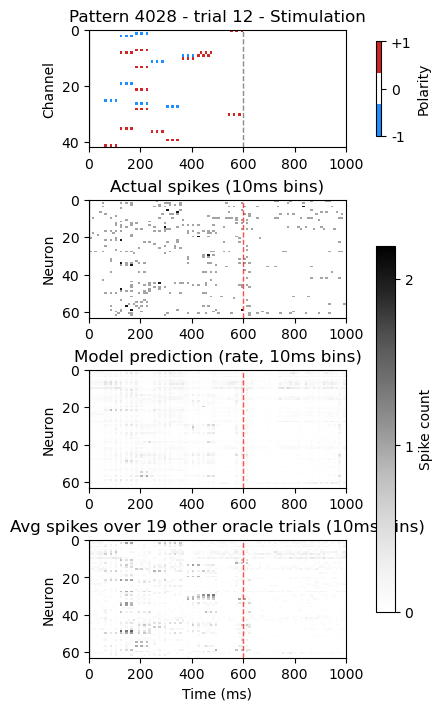

In [29]:
import importlib
import viz
importlib.reload(viz)
from viz import plot_oracle_trials_by_pattern
# Extract visualization config
PATTERN_LIMIT = cfg.get('pattern_limit', 50)

# Loop through oracle patterns and save per-pattern figures for trials 0-19
out_base = os.path.join(RUN_DIR, 'oracle_trials_by_pattern')

plot_oracle_trials_by_pattern(
    model=model,
    test_dataset=test_dataset,
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    pattern_polarities=pattern_polarities,
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    output_offset=OUTPUT_OFFSET,
    max_time_ms=1000,
    n_neurons=n_neurons,
    device=device,
    out_base=out_base,
    input_bin_size_ms=INPUT_BIN_SIZE_MS,
    logger=logger,
    pattern_limit=50,
    use_init_state=USE_INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    history=HISTORY
)

In [ ]:
# Test forward pass after training
batch = next(iter(train_loader))
if USE_INIT_STATE:
    sample_x, sample_y, sample_init = batch
    sample_x, sample_init = sample_x.to(device), sample_init.to(device)
else:
    sample_x, sample_y = batch
    sample_x = sample_x.to(device)
    sample_init = None

with torch.no_grad():
    if USE_INIT_STATE and hasattr(model, 'forward') and 'initial_spikes' in model.forward.__code__.co_varnames:
        sample_out = model(sample_x, initial_spikes=sample_init)
    else:
        sample_out = model(sample_x)

logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

assert sample_out.shape[1:] == sample_y.shape[1:], f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")

# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
neuron = 1
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, neuron, :].cpu().numpy()}")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {np.exp(sample_out[i, neuron, :].cpu().numpy())}")